In [0]:
%pip install xgboost

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# ============================================
# IMPORTOK
# ============================================

# PySpark
from pyspark.sql.functions import (
    col, month, dayofweek, to_timestamp, hour, datediff,
    sum as spark_sum, when, min as spark_min, max as spark_max,
    mean as spark_mean, avg, count, expr, round
)
from pyspark.sql.window import Window

# Pandas & NumPy
import pandas as pd
import numpy as np

# Scikit-learn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# XGBoost
import xgboost as xgb

# Vizualizáció
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

In [0]:
# === Adatbetöltés ===

file = "/Volumes/workspace/raw/files/aviation_delay.csv"
file_type = "csv"


infer_schema = "true"
first_row_is_header = "true"
delimiter = ","

df = spark.read.format(file_type) \
  .option("inferSchema", infer_schema) \
  .option("header", first_row_is_header) \
  .option("sep", delimiter) \
  .load(file)

display(df)

flight_datetime,origin,destination,scheduled_departure_hour,route_distance,aircraft_type,aircraft_age,turnaround_minutes,passenger_load_factor,visibility,wind_speed,precipitation,thunderstorm_flag,airport_congestion_index,runway_utilization,gate_availability,crew_rest_hours,crew_change_last_minute,previous_leg_delay,maintenance_events_last_30d,crew_status_new_FINAL,sched_buffer_mins_latest,ops_delay_prediction_v2,actual_gate_out_time_diff,maintenance_closed_after_pushback,final_delay_reason,actual_delay_minutes,delay_over_15m
2024-01-01T00:00:00.000Z,CDG,ZRH,0,1208.039459423142,E190,12.331888721336218,65.31929557634464,0.8955399272883509,7.993843647852289,33.45711669713797,2.008993534257067,0,42.65520030557965,0.8536271184569988,10.608771871165375,12.88516967244177,0,0.0,3.0,0,65.31929557634464,13.148093887812337,5.189945679751785,0,NONE,2.3739007768509572,0
2024-01-01T00:30:00.000Z,VIE,MAD,0,1324.0323036843954,E190,11.125741279747938,49.23908628278233,0.9470611956370658,10.471545723334042,18.732327126810397,1.0511953437272972,0,62.26962248558405,0.8035966647825161,8.509747021641136,12.05590485766761,0,11.884487683937392,null,0,49.23908628278233,3.674381341542154,3.5093319547534882,0,NONE,4.0498217890084875,0
2024-01-01T01:00:00.000Z,AMS,MUC,1,1198.2702097198644,B737,12.015662178829716,58.25214895786828,0.9324298601291039,6.697408502529732,31.28740182200867,1.4391315175420336,0,46.86018177951763,0.7760648747346417,13.105100714613362,13.432771954744227,0,22.047020413722564,1.0,0,58.25214895786828,14.52747425889074,-3.781593027055273,0,NONE,0.22504110438816427,0
2024-01-01T01:30:00.000Z,BUD,ZRH,1,1211.2510887799908,E190,10.005903275991129,42.24671707249878,0.7516991532596292,11.642091644515425,20.352171491116216,0.1843829805794983,0,56.333119040608686,0.9011587527857801,11.752022653057168,9.444036666933112,0,0.0,1.0,0,42.24671707249878,-1.3757451254028117,1.6572664959731407,0,NONE,8.432853990963931,0
2024-01-01T02:00:00.000Z,CDG,MUC,2,1039.4337625052744,E190,5.218236226590852,73.21300146043107,0.9338680967867422,9.213155074416509,9.479276213696231,1.4156377138522818,0,46.91250880205424,0.5955450191586547,14.488481062926654,10.539108484324718,0,14.196941884234011,null,0,73.21300146043107,11.24071573366043,-1.5184330808221005,0,NONE,1.237741973959034,0
2024-01-01T02:30:00.000Z,FCO,FRA,2,2328.6841274631133,B737,14.801825660503141,64.92339618822197,0.986005701657455,5.659472134261966,21.898872900767692,1.2435706497855583,0,64.47697357192608,0.5549804259092836,11.761810488734202,11.127043717640397,0,28.936704542649185,1.0,0,64.92339618822197,26.606775482177497,0.9304220569949007,0,NONE,1.4057097968041088,0
2024-01-01T03:00:00.000Z,ZRH,VIE,3,1321.6289461894426,B737,9.410334275372788,33.754521699352544,0.7539102026888668,null,20.67952779699598,1.9037087667375974,0,44.64629301507972,0.9070891623705835,7.461818579203422,9.186909437927467,0,0.0,0.0,0,33.754521699352544,-6.158084442306507,3.546734532288066,0,NONE,5.754678267293645,0
2024-01-01T03:30:00.000Z,CDG,BUD,3,1261.2368001721104,A321,5.2162429391183665,55.21206715377092,0.8801032021921689,null,22.99416172761267,0.5088919462490293,0,61.096762851581076,0.8849781818914084,16.271248729563826,13.565690083983423,0,0.5596403303802031,0.0,0,55.21206715377092,0.33404507997943766,3.6980809389617626,0,NONE,4.969315581025773,0
2024-01-01T04:00:00.000Z,AMS,LHR,4,1668.2858630028022,A319,4.4880847379530575,34.14282933788914,0.7524354960269182,9.468259749316177,18.826380249321016,2.6782267445807353,0,70.48854418842255,0.8480127351545059,8.111567905075514,12.187106106917556,0,41.16217612236081,0.0,0,34.14282933788914,35.21174644662783,16.145671497633945,0,NONE,14.678501892591425,0
2024-01-01T04:30:00.000Z,BUD,MAD,4,920.4741437839874,A320,5.3288032539999755,43.00756083922985,0.6743877048041292,4.444148732543311,13.205297016327368,4.358165298033345,0,54.004951135536615,0.6775672069779862,20.06767044305731,11.880397690858294,0,34.810692607373255,1.0,0,43.00756083922985,23.4814115276369,3.93655581780737

In [0]:
# === Időalapú feature-ök kinyerése ===
# A flight_datetime önmagában nem hasznos a modellnek, de a hónap és hét napja
# segíthet a heti/havi mintázatok megtanulásában.

df = df.withColumn("flight_datetime", to_timestamp(col("flight_datetime")))

df = df.withColumn("flight_month", month(col("flight_datetime")))
df = df.withColumn("flight_dayofweek", dayofweek(col("flight_datetime"))) # Vasárnap = 1, Hétfő = 2, stb.


display(df.select("flight_datetime", "flight_month", "flight_dayofweek", "scheduled_departure_hour").limit(5))


# Kiszámoljuk a null értékek számát minden oszlopra
null_counts = df.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c) 
    for c in df.columns
])

display(null_counts)


# === Időalapú problémák vizsgálata ===

# 1. Időtartomány
print("=== Időtartomány ===")
df.select(
    spark_min("flight_datetime").alias("min_date"),
    spark_max("flight_datetime").alias("max_date")
).show(truncate=False)

date_range = df.select(
    datediff(spark_max("flight_datetime"), spark_min("flight_datetime")).alias("days_covered")
).collect()[0]["days_covered"]
print(f"Lefedett napok száma: {date_range}")


# 2. Óra-konzisztencia: flight_datetime órája = scheduled_departure_hour?
print("\n=== Óra-konzisztencia ===")
total_rows = df.count()
mismatch = df.filter(hour(col("flight_datetime")) != col("scheduled_departure_hour")).count()
print(f"Összes sor: {total_rows}")
print(f"Eltérő órák száma: {mismatch}")
print(f"Eltérés aránya: {mismatch/total_rows*100:.2f}%")


# 3. Duplikátumok: ugyanaz a járat (datetime + origin + destination) többször?
print("\n=== Duplikátumok ===")
unique_flights = df.select("flight_datetime", "origin", "destination").distinct().count()
print(f"Egyedi (datetime + origin + destination) kombinációk: {unique_flights}")
print(f"Duplikátumok száma: {total_rows - unique_flights}")


# 4. Sorok havi eloszlása
print("\n=== Sorok havi eloszlása ===")
df.groupBy("flight_month").count().orderBy("flight_month").show()

flight_datetime,flight_month,flight_dayofweek,scheduled_departure_hour
2024-01-01T00:00:00.000Z,1,2,0
2024-01-01T00:30:00.000Z,1,2,0
2024-01-01T01:00:00.000Z,1,2,1
2024-01-01T01:30:00.000Z,1,2,1
2024-01-01T02:00:00.000Z,1,2,2


flight_datetime,origin,destination,scheduled_departure_hour,route_distance,aircraft_type,aircraft_age,turnaround_minutes,passenger_load_factor,visibility,wind_speed,precipitation,thunderstorm_flag,airport_congestion_index,runway_utilization,gate_availability,crew_rest_hours,crew_change_last_minute,previous_leg_delay,maintenance_events_last_30d,crew_status_new_FINAL,sched_buffer_mins_latest,ops_delay_prediction_v2,actual_gate_out_time_diff,maintenance_closed_after_pushback,final_delay_reason,actual_delay_minutes,delay_over_15m,flight_month,flight_dayofweek
0,0,0,0,0,0,0,0,0,464,0,0,0,0,0,0,0,0,0,722,0,0,0,0,0,0,0,0,0,0


=== Időtartomány ===
+-------------------+-------------------+
|min_date           |max_date           |
+-------------------+-------------------+
|2024-01-01 00:00:00|2024-05-04 23:30:00|
+-------------------+-------------------+

Lefedett napok száma: 124

=== Óra-konzisztencia ===
Összes sor: 6000
Eltérő órák száma: 0
Eltérés aránya: 0.00%

=== Duplikátumok ===
Egyedi (datetime + origin + destination) kombinációk: 6000
Duplikátumok száma: 0

=== Sorok havi eloszlása ===
+------------+-----+
|flight_month|count|
+------------+-----+
|           1| 1488|
|           2| 1392|
|           3| 1488|
|           4| 1440|
|           5|  192|
+------------+-----+



In [0]:


# visibility hiányok eloszlása origin szerint
print("=== visibility hiányok origin szerint ===")
df.filter(col("visibility").isNull()) \
  .groupBy("origin").count().orderBy(col("count").desc()).show()

print("=== Összes sor origin szerint (referencia) ===")
df.groupBy("origin").count().orderBy(col("count").desc()).show()


# maintenance_events_last_30d hiányok — összefügg-e az aircraft_age-zsel?
print("=== aircraft_age statisztika ahol maintenance hiányzik vs nem hiányzik ===")
df.groupBy(col("maintenance_events_last_30d").isNull().alias("maintenance_missing")) \
  .agg(
      spark_mean("aircraft_age").alias("avg_aircraft_age"),
      spark_min("aircraft_age").alias("min_aircraft_age"),
      spark_max("aircraft_age").alias("max_aircraft_age")
  ).show()

# maintenance hiányok aircraft_type szerint
print("=== Összes sor aircraft_type szerint (referencia) ===")
df.groupBy("aircraft_type").count().orderBy(col("count").desc()).show()

print("=== maintenance hiányok aircraft_type szerint ===")
df.filter(col("maintenance_events_last_30d").isNull()) \
  .groupBy("aircraft_type").count().orderBy(col("count").desc()).show()



=== visibility hiányok origin szerint ===
+------+-----+
|origin|count|
+------+-----+
|   LHR|   59|
|   MUC|   56|
|   CDG|   49|
|   BUD|   48|
|   FRA|   47|
|   FCO|   44|
|   VIE|   43|
|   AMS|   43|
|   MAD|   39|
|   ZRH|   36|
+------+-----+

=== Összes sor origin szerint (referencia) ===
+------+-----+
|origin|count|
+------+-----+
|   LHR|  631|
|   FRA|  620|
|   ZRH|  615|
|   AMS|  605|
|   CDG|  596|
|   VIE|  592|
|   FCO|  590|
|   MAD|  589|
|   BUD|  587|
|   MUC|  575|
+------+-----+

=== aircraft_age statisztika ahol maintenance hiányzik vs nem hiányzik ===
+-------------------+-----------------+----------------+------------------+
|maintenance_missing| avg_aircraft_age|min_aircraft_age|  max_aircraft_age|
+-------------------+-----------------+----------------+------------------+
|               true|9.010091489817345|             0.0|21.864080672084675|
|              false|8.965546126338241|             0.0|22.270748215939953|
+-------------------+-------------

In [0]:
# Tényleg eltér a típusonkénti medián?
print("=== maintenance_events_last_30d medián aircraft_type szerint ===")
df.groupBy("aircraft_type") \
  .agg(spark_mean("maintenance_events_last_30d").alias("avg"),
       spark_min("maintenance_events_last_30d").alias("min"),
       spark_max("maintenance_events_last_30d").alias("max")) \
  .orderBy("aircraft_type").show()

print("=== visibility medián origin szerint ===")
df.groupBy("origin") \
  .agg(spark_mean("visibility").alias("avg"),
       spark_min("visibility").alias("min"),
       spark_max("visibility").alias("max")) \
  .orderBy("origin").show()

=== maintenance_events_last_30d medián aircraft_type szerint ===
+-------------+------------------+---+----+
|aircraft_type|               avg|min| max|
+-------------+------------------+---+----+
|         A319|1.7131782945736433|0.0| 7.0|
|         A320| 1.809478672985782|0.0|10.0|
|         A321|1.7733580018501387|0.0| 8.0|
|         B737|1.7921348314606742|0.0| 7.0|
|         E190| 1.838771593090211|0.0| 8.0|
+-------------+------------------+---+----+

=== visibility medián origin szerint ===
+------+-----------------+---+----+
|origin|              avg|min| max|
+------+-----------------+---+----+
|   AMS|8.217688677853452|0.1|15.0|
|   BUD|7.937099172059881|0.1|15.0|
|   CDG|7.755873899177558|0.1|15.0|
|   FCO| 8.04465032162785|0.1|15.0|
|   FRA|8.083110451213017|0.1|15.0|
|   LHR|8.048891547370136|0.1|15.0|
|   MAD|8.100002723216711|0.1|15.0|
|   MUC|8.028218960666727|0.1|15.0|
|   VIE|8.101219326653078|0.1|15.0|
|   ZRH|7.885362359742569|0.1|15.0|
+------+-----------------+---

In [0]:
# --- 1. VISIBILITY: Pótlás az adott reptér (origin) mediánjával ---

# A) Létrehozzuk a flag oszlopot (1 = hiányzott, 0 = megvolt)
df = df.withColumn("visibility_missing_flag", col("visibility").isNull().cast("int"))

# B) Definiáljuk az "ablakot" (csoportosítás origin szerint)
window_origin = Window.partitionBy("origin")

# C) Kiszámoljuk az origin-specifikus mediánt (percentile_approx) és beírjuk a nullok helyére
df = df.withColumn(
    "visibility",
    when(
        col("visibility").isNull(), 
        expr("percentile_approx(visibility, 0.5)").over(window_origin)
    ).otherwise(col("visibility"))
)

# --- 2. MAINTENANCE: Pótlás az adott géptípus (aircraft_type) mediánjával ---

# A) Létrehozzuk a flag oszlopot
df = df.withColumn("maintenance_missing_flag", col("maintenance_events_last_30d").isNull().cast("int"))

# B) Definiáljuk az "ablakot" (csoportosítás aircraft_type szerint)
window_aircraft = Window.partitionBy("aircraft_type")

# C) Kiszámoljuk a géptípus-specifikus mediánt és beírjuk a nullok helyére
df = df.withColumn(
    "maintenance_events_last_30d",
    when(
        col("maintenance_events_last_30d").isNull(), 
        expr("percentile_approx(maintenance_events_last_30d, 0.5)").over(window_aircraft)
    ).otherwise(col("maintenance_events_last_30d"))
)

# Ellenőrzés, hogy eltűntek-e a null értékek
print("Maradék null értékek:")
df.select("visibility", "maintenance_events_last_30d").summary("count").show()

Maradék null értékek:
+-------+----------+---------------------------+
|summary|visibility|maintenance_events_last_30d|
+-------+----------+---------------------------+
|  count|      6000|                       6000|
+-------+----------+---------------------------+



In [0]:
print("=== Célváltozó (delay_over_15m) eloszlása ===")
total_rows = df.count()

# Kiszámoljuk a darabszámot és a százalékos arányt
target_dist = df.groupBy("delay_over_15m").count() \
    .withColumn("percentage (%)", round((col("count") / total_rows) * 100, 2))

display(target_dist)





print("=== Címke-konzisztencia ===")
df.select(
    spark_sum(when((col("actual_delay_minutes") > 15) & (col("delay_over_15m") == 0), 1).otherwise(0)).alias("should_be_1_but_0"),
    spark_sum(when((col("actual_delay_minutes") <= 15) & (col("delay_over_15m") == 1), 1).otherwise(0)).alias("should_be_0_but_1")
).show()





print("=== actual_delay_minutes eloszlása ===")
df.select("actual_delay_minutes").summary("count", "min", "25%", "50%", "75%", "max", "mean", "stddev").show()

# Negatív értékek (early departure)
neg = df.filter(col("actual_delay_minutes") < 0).count()
print(f"Negatív actual_delay_minutes (korai indulás): {neg}")

=== Célváltozó (delay_over_15m) eloszlása ===


delay_over_15m,count,percentage (%)
1,238,3.97
0,5762,96.03


=== Címke-konzisztencia ===
+-----------------+-----------------+
|should_be_1_but_0|should_be_0_but_1|
+-----------------+-----------------+
|              134|               29|
+-----------------+-----------------+

=== actual_delay_minutes eloszlása ===
+-------+--------------------+
|summary|actual_delay_minutes|
+-------+--------------------+
|  count|                6000|
|    min|2.418386050664999...|
|    25%|  1.2364393602300325|
|    50%|   2.902566130735145|
|    75%|  6.1684263270300645|
|    max|  125.59072556533695|
|   mean|   5.309755897968752|
| stddev|   8.400873992980868|
+-------+--------------------+

Negatív actual_delay_minutes (korai indulás): 0


In [0]:
# === 1. Célváltozó újradefiniálása az actual_delay_minutes alapján ===
df = df.withColumn("delay_over_15m", when(col("actual_delay_minutes") > 15, 1).otherwise(0))
print("Célváltozó újradefiniálva az actual_delay_minutes > 15 szabály alapján.")

# Új eloszlás ellenőrzése
print("\n=== Új célváltozó eloszlása ===")
df.groupBy("delay_over_15m").count().orderBy("delay_over_15m").show()
positive = df.filter(col("delay_over_15m") == 1).count()
total = df.count()
print(f"Új pozitív arány: {positive/total*100:.2f}%")


# === 2. Gyanús oszlopok korrelációja a célváltozóval ===
print("\n=== Gyanús numerikus oszlopok korrelációja ===")
suspicious_cols = ["ops_delay_prediction_v2", "sched_buffer_mins_latest", "previous_leg_delay", "actual_gate_out_time_diff", "crew_status_new_FINAL"]

for col_name in suspicious_cols:
    correlation = df.stat.corr(col_name, "delay_over_15m")
    print(f"{col_name:35s} korreláció: {correlation:.4f}")


# === 3. crew_status_new_FINAL kategorikus eloszlás ===
print("\n=== crew_status_new_FINAL kategória eloszlása ===")
df.groupBy("crew_status_new_FINAL").count().orderBy("count", ascending=False).show()


# === 4. maintenance_closed_after_pushback és final_delay_reason ellenőrzése ===
print("\n=== final_delay_reason kategóriák ===")
df.groupBy("final_delay_reason").count().orderBy("count", ascending=False).show()

print("\n=== maintenance_closed_after_pushback eloszlás ===")
df.groupBy("maintenance_closed_after_pushback").count().show()

Célváltozó újradefiniálva az actual_delay_minutes > 15 szabály alapján.

=== Új célváltozó eloszlása ===
+--------------+-----+
|delay_over_15m|count|
+--------------+-----+
|             0| 5657|
|             1|  343|
+--------------+-----+

Új pozitív arány: 5.72%

=== Gyanús numerikus oszlopok korrelációja ===
ops_delay_prediction_v2             korreláció: 0.0917
sched_buffer_mins_latest            korreláció: -0.0555
previous_leg_delay                  korreláció: 0.0961
actual_gate_out_time_diff           korreláció: 0.7292
crew_status_new_FINAL               korreláció: 0.0220

=== crew_status_new_FINAL kategória eloszlása ===
+---------------------+-----+
|crew_status_new_FINAL|count|
+---------------------+-----+
|                    0| 5501|
|                    1|  499|
+---------------------+-----+


=== final_delay_reason kategóriák ===
+------------------+-----+
|final_delay_reason|count|
+------------------+-----+
|              NONE| 5762|
|               ATC|   66|
| 

In [0]:
leakage_cols = [
    "actual_delay_minutes", 
    "actual_gate_out_time_diff", 
    "maintenance_closed_after_pushback", 
    "final_delay_reason"
]

df = df.drop(*leakage_cols)

print(f"Szivárgó oszlopok eldobva. Jelenlegi oszlopok száma: {len(df.columns)}")

Szivárgó oszlopok eldobva. Jelenlegi oszlopok száma: 28


In [0]:
# Segédfüggvény a kiíratáshoz
def show_delay_pattern(df, group_col, sort_by_rate=True):
    print(f"=== Késési arány: {group_col} szerint ===")
    result = df.groupBy(group_col).agg(
        count("*").alias("total_flights"),
        spark_sum("delay_over_15m").alias("delayed_flights"),
        (avg("delay_over_15m") * 100).alias("delay_rate_pct")
    )
    if sort_by_rate:
        result = result.orderBy(col("delay_rate_pct").desc())
    else:
        result = result.orderBy(group_col)
    result.show(30)


# === 1. aircraft_type (kategorikus) ===
show_delay_pattern(df, "aircraft_type")


# === 2. route_distance (numerikus → binnelve) ===
df_with_bins = df.withColumn("route_distance_bin",
    when(col("route_distance") < 500, "0-500 km")
    .when(col("route_distance") < 1000, "500-1000 km")
    .when(col("route_distance") < 1500, "1000-1500 km")
    .when(col("route_distance") < 2000, "1500-2000 km")
    .otherwise("2000+ km")
)
show_delay_pattern(df_with_bins, "route_distance_bin", sort_by_rate=False)


# === 3. aircraft_age (numerikus → binnelve) ===
df_with_bins = df_with_bins.withColumn("aircraft_age_bin",
    when(col("aircraft_age") < 5, "0-5 év")
    .when(col("aircraft_age") < 10, "5-10 év")
    .when(col("aircraft_age") < 15, "10-15 év")
    .when(col("aircraft_age") < 20, "15-20 év")
    .otherwise("20+ év")
)
show_delay_pattern(df_with_bins, "aircraft_age_bin", sort_by_rate=False)


# === 4. visibility (numerikus → binnelve) ===
# Először nézzük meg a tartományt
print("=== visibility tartomány ===")
df.select("visibility").summary("min", "25%", "50%", "75%", "max").show()

# A binneket az adat alapján kell beállítani — most kvartilisek szerint
df_with_bins = df_with_bins.withColumn("visibility_bin",
    when(col("visibility") < 5, "alacsony (<5)")
    .when(col("visibility") < 10, "közepes (5-10)")
    .when(col("visibility") < 15, "jó (10-15)")
    .otherwise("kiváló (15+)")
)
show_delay_pattern(df_with_bins, "visibility_bin", sort_by_rate=False)


# === 5. wind_speed (numerikus → binnelve) ===
print("=== wind_speed tartomány ===")
df.select("wind_speed").summary("min", "25%", "50%", "75%", "max").show()


# === 6. precipitation (numerikus → binnelve) ===
print("=== precipitation tartomány ===")
df.select("precipitation").summary("min", "25%", "50%", "75%", "max").show()


# === 7. previous_leg_delay (numerikus → binnelve) ===
print("=== previous_leg_delay tartomány ===")
df.select("previous_leg_delay").summary("min", "25%", "50%", "75%", "max").show()


# === 8. turnaround_minutes (numerikus → binnelve) ===
print("=== turnaround_minutes tartomány ===")
df.select("turnaround_minutes").summary("min", "25%", "50%", "75%", "max").show()

=== Késési arány: aircraft_type szerint ===
+-------------+-------------+---------------+------------------+
|aircraft_type|total_flights|delayed_flights|    delay_rate_pct|
+-------------+-------------+---------------+------------------+
|         B737|         1194|             77| 6.448911222780569|
|         A319|         1161|             70| 6.029285099052541|
|         A321|         1244|             71| 5.707395498392283|
|         A320|         1194|             68|5.6951423785594635|
|         E190|         1207|             57| 4.722452361226181|
+-------------+-------------+---------------+------------------+

=== Késési arány: route_distance_bin szerint ===
+------------------+-------------+---------------+-----------------+
|route_distance_bin|total_flights|delayed_flights|   delay_rate_pct|
+------------------+-------------+---------------+-----------------+
|          0-500 km|          446|             31|6.950672645739911|
|      1000-1500 km|         2251|           

# MODELLEZÉS

In [0]:
# === 1. Konverzió és a tisztítás ===
pandas_df = df.toPandas()


pandas_df = pandas_df.sort_values('flight_datetime').reset_index(drop=True)
pandas_df = pandas_df.drop(columns=['flight_datetime'])

# === 2. ONE-HOT ENCODING ===
# A szöveges oszlopokat átalakítjuk számokká
categorical_cols = ['origin', 'destination', 'aircraft_type']
pandas_df = pd.get_dummies(pandas_df, columns=categorical_cols, drop_first=True)

# === 3. Train / Validation / Test felosztás (Időalapú) ===
n = len(pandas_df)
train_idx = int(n * 0.70)
val_idx = int(n * 0.85)

X = pandas_df.drop(columns=['delay_over_15m'])
y = pandas_df['delay_over_15m']

X_train, y_train = X.iloc[:train_idx], y.iloc[:train_idx]
X_val, y_val = X.iloc[train_idx:val_idx], y.iloc[train_idx:val_idx]
X_test, y_test = X.iloc[val_idx:], y.iloc[val_idx:]

print(f"Train méret: {len(X_train)} | Val méret: {len(X_val)} | Test méret: {len(X_test)}")

# === 4. Univerzális Kiértékelő Függvény ===
def evaluate_model(model_name, y_true, y_pred, y_pred_proba=None):
    print(f"\n{'='*40}")
    print(f" MODELL KIÉRTÉKELÉS: {model_name}")
    print(f"{'='*40}")
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_true, y_pred_proba)
        pr_auc = average_precision_score(y_true, y_pred_proba)
        print(f"ROC-AUC:   {roc_auc:.4f}")
        print(f"PR-AUC:    {pr_auc:.4f}")
        
    print("\nConfusion Matrix (Tényleges sorok, Jósolt oszlopok):")
    print(confusion_matrix(y_true, y_pred))
    print("-"*40)

# === 5. BASELINE MODELLEK FUTTATÁSA A VALIDÁCIÓS HALMAZON ===

# 1. Baseline: Dummy (Mindig azt mondja, hogy NEM késik)
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train, y_train)
evaluate_model("1. Dummy Baseline (Mindig 0)", y_val, dummy_clf.predict(X_val), dummy_clf.predict_proba(X_val)[:, 1])

# 2. Baseline: Üzleti Szabály (Ha az előző úton késett > 15 percet)
rule_preds = (X_val['previous_leg_delay'] > 15).astype(int)
evaluate_model("2. Üzleti Szabály (previous_leg_delay > 15)", y_val, rule_preds)

# 3. Baseline: Logistic Regression (Súlyozott)
log_reg = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
log_reg.fit(X_train, y_train)
evaluate_model("3. Logistic Regression", y_val, log_reg.predict(X_val), log_reg.predict_proba(X_val)[:, 1])

Train méret: 4200 | Val méret: 900 | Test méret: 900

 MODELL KIÉRTÉKELÉS: 1. Dummy Baseline (Mindig 0)
Accuracy:  0.9411
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000
ROC-AUC:   0.5000
PR-AUC:    0.0589

Confusion Matrix (Tényleges sorok, Jósolt oszlopok):
[[847   0]
 [ 53   0]]
----------------------------------------

 MODELL KIÉRTÉKELÉS: 2. Üzleti Szabály (previous_leg_delay > 15)
Accuracy:  0.5889
Precision: 0.0862
Recall:    0.6226
F1-score:  0.1514

Confusion Matrix (Tényleges sorok, Jósolt oszlopok):
[[497 350]
 [ 20  33]]
----------------------------------------

 MODELL KIÉRTÉKELÉS: 3. Logistic Regression
Accuracy:  0.6956
Precision: 0.0952
Recall:    0.4906
F1-score:  0.1595
ROC-AUC:   0.6729
PR-AUC:    0.1318

Confusion Matrix (Tényleges sorok, Jósolt oszlopok):
[[600 247]
 [ 27  26]]
----------------------------------------


/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [0]:
print("\n" + "="*50)
print(" KOMPLEX MODELLEK FUTTATÁSA A VALIDÁCIÓS HALMAZON")
print("="*50)

# === 4. Modell: Random Forest ===
# A class_weight='balanced_subsample' automatikusan kezeli az imbalanced adatot
rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=7, 
    class_weight='balanced_subsample', 
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

evaluate_model("4. Random Forest Classifier", 
               y_val, 
               rf_model.predict(X_val), 
               rf_model.predict_proba(X_val)[:, 1])

# === 5. Modell: XGBoost ===
# Kiszámoljuk a negatív/pozitív osztályok arányát az XGBoost-hoz (imbalanced kezelés)
scale_pos_weight_value = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight_value,
    random_state=42,
    eval_metric='aucpr',
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

evaluate_model("5. XGBoost Classifier", 
               y_val, 
               xgb_model.predict(X_val), 
               xgb_model.predict_proba(X_val)[:, 1])


 KOMPLEX MODELLEK FUTTATÁSA A VALIDÁCIÓS HALMAZON

 MODELL KIÉRTÉKELÉS: 4. Random Forest Classifier
Accuracy:  0.9322
Precision: 0.2500
Recall:    0.0755
F1-score:  0.1159
ROC-AUC:   0.6132
PR-AUC:    0.1078

Confusion Matrix (Tényleges sorok, Jósolt oszlopok):
[[835  12]
 [ 49   4]]
----------------------------------------


/local_disk0/.ephemeral_nfs/envs/pythonEnv-6790944d-ca14-4995-91dd-a75178cb47c6/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [20:14:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 MODELL KIÉRTÉKELÉS: 5. XGBoost Classifier
Accuracy:  0.9089
Precision: 0.1463
Recall:    0.1132
F1-score:  0.1277
ROC-AUC:   0.5822
PR-AUC:    0.0875

Confusion Matrix (Tényleges sorok, Jósolt oszlopok):
[[812  35]
 [ 47   6]]
----------------------------------------


In [0]:
print("\n" + "="*60)
print(" VÉGSŐ TESZT: AZ ÖSSZES MODELL A TEST HALMAZON (Utolsó 15%)")
print("="*60)

# 1. Dummy Baseline
evaluate_model("VÉGSŐ TESZT - 1. Dummy Baseline", 
               y_test, 
               dummy_clf.predict(X_test), 
               dummy_clf.predict_proba(X_test)[:, 1])

# 2. Üzleti Szabály (Kézi predikció a teszt halmazon)
rule_preds_test = (X_test['previous_leg_delay'] > 15).astype(int)
evaluate_model("VÉGSŐ TESZT - 2. Üzleti Szabály", 
               y_test, 
               rule_preds_test)

# 3. Logisztikai Regresszió (A mi titkos esélyesünk)
evaluate_model("VÉGSŐ TESZT - 3. Logistic Regression", 
               y_test, 
               log_reg.predict(X_test), 
               log_reg.predict_proba(X_test)[:, 1])

# 4. Random Forest
evaluate_model("VÉGSŐ TESZT - 4. Random Forest Classifier", 
               y_test, 
               rf_model.predict(X_test), 
               rf_model.predict_proba(X_test)[:, 1])

# 5. XGBoost
evaluate_model("VÉGSŐ TESZT - 5. XGBoost Classifier", 
               y_test, 
               xgb_model.predict(X_test), 
               xgb_model.predict_proba(X_test)[:, 1])


 VÉGSŐ TESZT: AZ ÖSSZES MODELL A TEST HALMAZON (Utolsó 15%)

 MODELL KIÉRTÉKELÉS: VÉGSŐ TESZT - 1. Dummy Baseline
Accuracy:  0.9322
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000
ROC-AUC:   0.5000
PR-AUC:    0.0678

Confusion Matrix (Tényleges sorok, Jósolt oszlopok):
[[839   0]
 [ 61   0]]
----------------------------------------

 MODELL KIÉRTÉKELÉS: VÉGSŐ TESZT - 2. Üzleti Szabály
Accuracy:  0.5856
Precision: 0.0829
Recall:    0.5082
F1-score:  0.1425

Confusion Matrix (Tényleges sorok, Jósolt oszlopok):
[[496 343]
 [ 30  31]]
----------------------------------------

 MODELL KIÉRTÉKELÉS: VÉGSŐ TESZT - 3. Logistic Regression
Accuracy:  0.7089
Precision: 0.0795
Recall:    0.3115
F1-score:  0.1267
ROC-AUC:   0.5399
PR-AUC:    0.0993

Confusion Matrix (Tényleges sorok, Jósolt oszlopok):
[[619 220]
 [ 42  19]]
----------------------------------------

 MODELL KIÉRTÉKELÉS: VÉGSŐ TESZT - 4. Random Forest Classifier
Accuracy:  0.9211
Precision: 0.2222
Recall:    0.0656
F1-score:  0

# Business interpretation

In [0]:
sns.set_theme(style="whitegrid")

# Az összes modell predikciója a TEST halmazon
predictions = {
    "Dummy": {
        "y_pred": dummy_clf.predict(X_test),
        "y_proba": dummy_clf.predict_proba(X_test)[:, 1],
        "color": "gray",
        "linestyle": "--"
    },
    "Üzleti szabály": {
        "y_pred": (X_test['previous_leg_delay'] > 15).astype(int).values,
        "y_proba": None,
        "color": "#8c564b",
        "linestyle": ":"
    },
    "Logistic Regression": {
        "y_pred": log_reg.predict(X_test),
        "y_proba": log_reg.predict_proba(X_test)[:, 1],
        "color": "#ff7f0e",
        "linestyle": "-"
    },
    "Random Forest": {
        "y_pred": rf_model.predict(X_test),
        "y_proba": rf_model.predict_proba(X_test)[:, 1],
        "color": "#2ca02c",
        "linestyle": "-"
    },
    "XGBoost": {
        "y_pred": xgb_model.predict(X_test),
        "y_proba": xgb_model.predict_proba(X_test)[:, 1],
        "color": "#9467bd",
        "linestyle": "-"
    }
}

baseline_models = ["Dummy", "Üzleti szabály", "Logistic Regression"]
advanced_models = ["Logistic Regression", "Random Forest", "XGBoost"]

# Metrikák összegyűjtése
metrics_data = []
for name, p in predictions.items():
    row = {
        "Modell": name,
        "Accuracy": accuracy_score(y_test, p["y_pred"]),
        "Precision": precision_score(y_test, p["y_pred"], zero_division=0),
        "Recall": recall_score(y_test, p["y_pred"], zero_division=0),
        "F1": f1_score(y_test, p["y_pred"], zero_division=0),
    }
    if p["y_proba"] is not None:
        row["PR-AUC"] = average_precision_score(y_test, p["y_proba"])
        row["ROC-AUC"] = roc_auc_score(y_test, p["y_proba"])
    else:
        row["PR-AUC"] = np.nan
        row["ROC-AUC"] = np.nan
    metrics_data.append(row)

metrics_df = pd.DataFrame(metrics_data)
print("=== Test halmaz metrikák ===")
print(metrics_df.round(4).to_string(index=False))

=== Test halmaz metrikák ===
             Modell  Accuracy  Precision  Recall     F1  PR-AUC  ROC-AUC
              Dummy    0.9322     0.0000  0.0000 0.0000  0.0678   0.5000
     Üzleti szabály    0.5856     0.0829  0.5082 0.1425     NaN      NaN
Logistic Regression    0.7089     0.0795  0.3115 0.1267  0.0993   0.5399
      Random Forest    0.9211     0.2222  0.0656 0.1013  0.1104   0.5462
            XGBoost    0.8956     0.1163  0.0820 0.0962  0.0912   0.5132


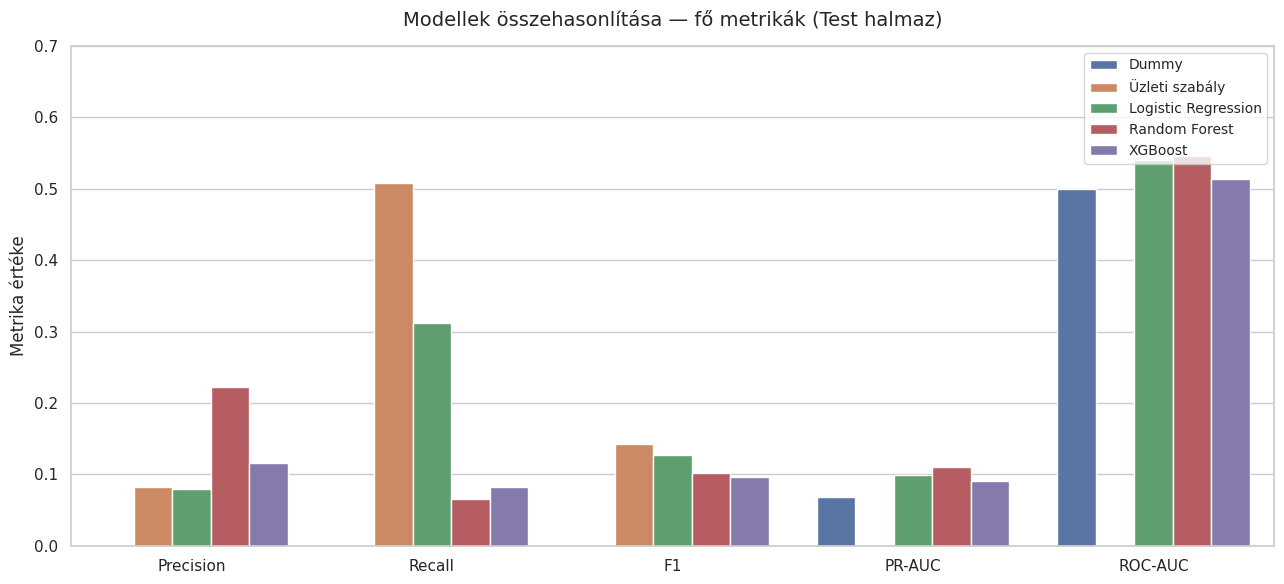

In [0]:
metrics_long = metrics_df.melt(id_vars="Modell", var_name="Metrika", value_name="Érték")
metrics_long = metrics_long[metrics_long["Metrika"].isin(["Precision", "Recall", "F1", "PR-AUC", "ROC-AUC"])]

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=metrics_long, x="Metrika", y="Érték", hue="Modell", ax=ax)
ax.set_title("Modellek összehasonlítása — fő metrikák (Test halmaz)", fontsize=14, pad=15)
ax.set_ylabel("Metrika értéke")
ax.set_xlabel("")
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(0, max(0.7, metrics_long["Érték"].max() * 1.1))
plt.tight_layout()
plt.show()

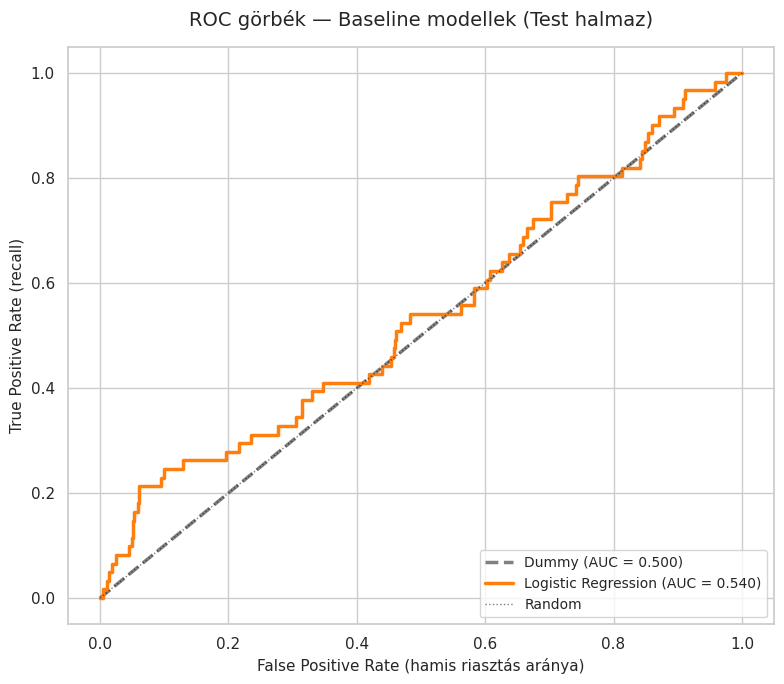

In [0]:
fig, ax = plt.subplots(figsize=(8, 7))

for name in baseline_models:
    p = predictions[name]
    if p["y_proba"] is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, p["y_proba"])
    auc = roc_auc_score(y_test, p["y_proba"])
    ax.plot(fpr, tpr, color=p["color"], linestyle=p["linestyle"],
            linewidth=2.5, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], color='black', linestyle=':', linewidth=1, alpha=0.5, label="Random")
ax.set_xlabel("False Positive Rate (hamis riasztás aránya)", fontsize=11)
ax.set_ylabel("True Positive Rate (recall)", fontsize=11)
ax.set_title("ROC görbék — Baseline modellek (Test halmaz)", fontsize=14, pad=15)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

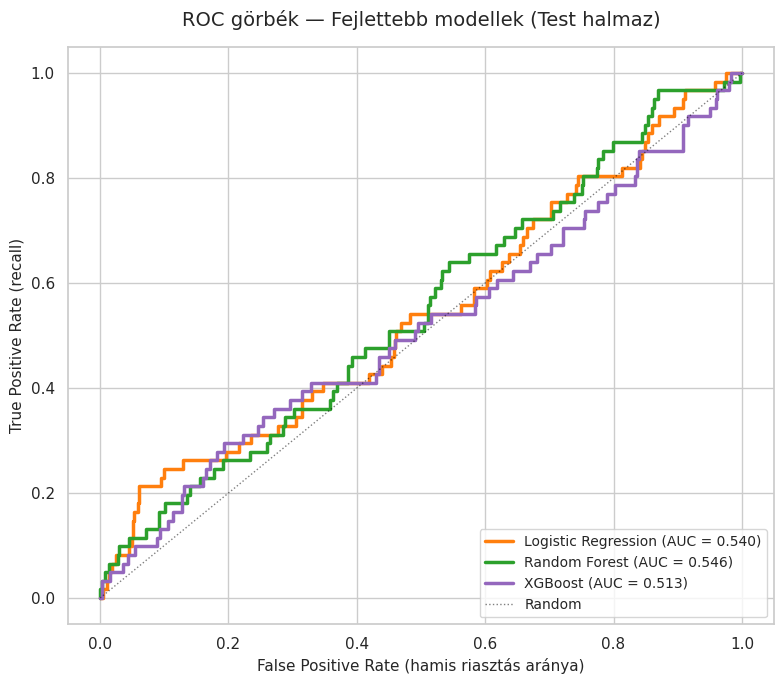

In [0]:
fig, ax = plt.subplots(figsize=(8, 7))

for name in advanced_models:
    p = predictions[name]
    if p["y_proba"] is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, p["y_proba"])
    auc = roc_auc_score(y_test, p["y_proba"])
    ax.plot(fpr, tpr, color=p["color"], linestyle=p["linestyle"],
            linewidth=2.5, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], color='black', linestyle=':', linewidth=1, alpha=0.5, label="Random")
ax.set_xlabel("False Positive Rate (hamis riasztás aránya)", fontsize=11)
ax.set_ylabel("True Positive Rate (recall)", fontsize=11)
ax.set_title("ROC görbék — Fejlettebb modellek (Test halmaz)", fontsize=14, pad=15)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

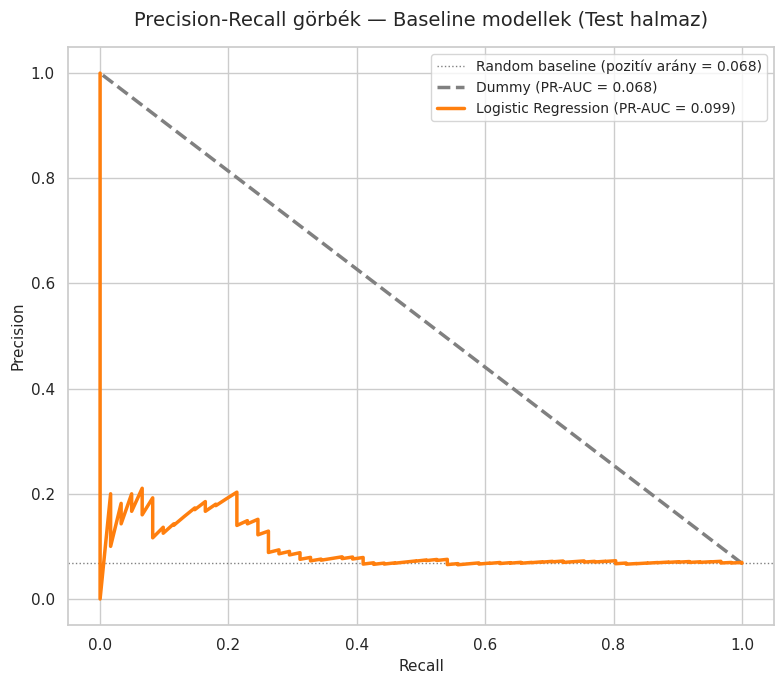

In [0]:
fig, ax = plt.subplots(figsize=(8, 7))

positive_rate = y_test.mean()
ax.axhline(y=positive_rate, color='black', linestyle=':', linewidth=1, alpha=0.5,
           label=f"Random baseline (pozitív arány = {positive_rate:.3f})")

for name in baseline_models:
    p = predictions[name]
    if p["y_proba"] is None:
        continue
    precision, recall, _ = precision_recall_curve(y_test, p["y_proba"])
    pr_auc = average_precision_score(y_test, p["y_proba"])
    ax.plot(recall, precision, color=p["color"], linestyle=p["linestyle"],
            linewidth=2.5, label=f"{name} (PR-AUC = {pr_auc:.3f})")

ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision-Recall görbék — Baseline modellek (Test halmaz)", fontsize=14, pad=15)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

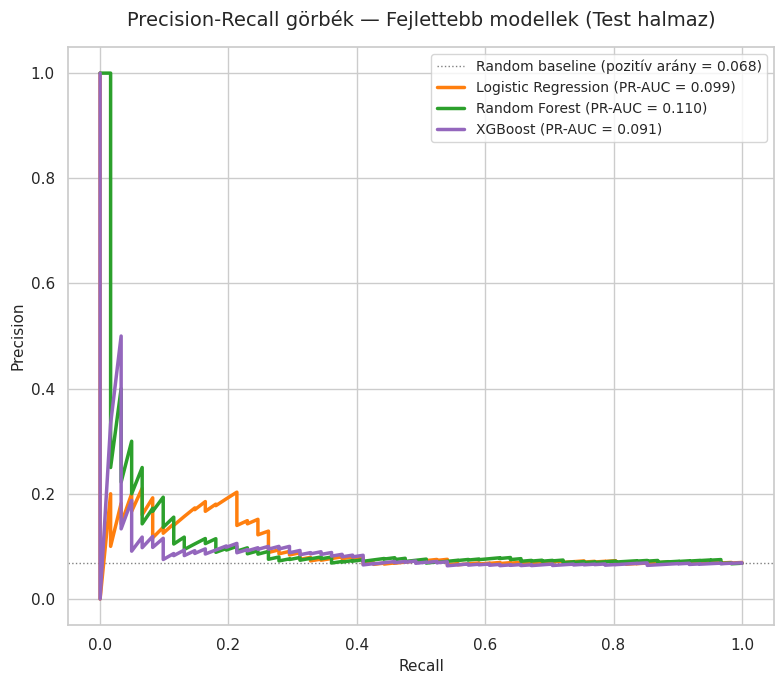

In [0]:
fig, ax = plt.subplots(figsize=(8, 7))

positive_rate = y_test.mean()
ax.axhline(y=positive_rate, color='black', linestyle=':', linewidth=1, alpha=0.5,
           label=f"Random baseline (pozitív arány = {positive_rate:.3f})")

for name in advanced_models:
    p = predictions[name]
    if p["y_proba"] is None:
        continue
    precision, recall, _ = precision_recall_curve(y_test, p["y_proba"])
    pr_auc = average_precision_score(y_test, p["y_proba"])
    ax.plot(recall, precision, color=p["color"], linestyle=p["linestyle"],
            linewidth=2.5, label=f"{name} (PR-AUC = {pr_auc:.3f})")

ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision-Recall görbék — Fejlettebb modellek (Test halmaz)", fontsize=14, pad=15)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

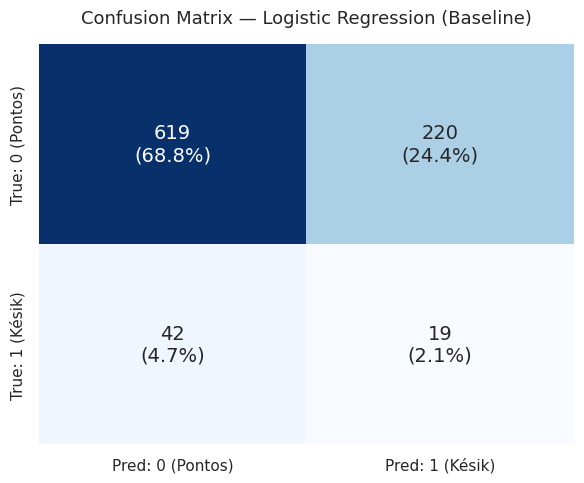

In [0]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, predictions["Logistic Regression"]["y_pred"])
cm_pct = cm / cm.sum() * 100
labels = [[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)]

sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, 
            annot_kws={"size": 14}, ax=ax,
            xticklabels=["Pred: 0 (Pontos)", "Pred: 1 (Késik)"],
            yticklabels=["True: 0 (Pontos)", "True: 1 (Késik)"])
ax.set_title("Confusion Matrix — Logistic Regression (Baseline)", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

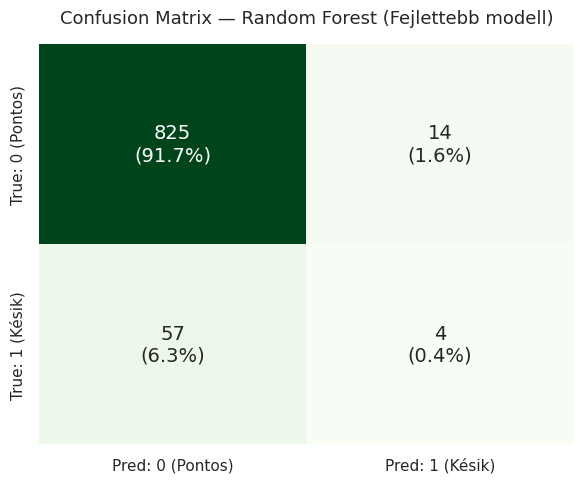

In [0]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, predictions["Random Forest"]["y_pred"])
cm_pct = cm / cm.sum() * 100
labels = [[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)]

sns.heatmap(cm, annot=labels, fmt='', cmap='Greens', cbar=False, 
            annot_kws={"size": 14}, ax=ax,
            xticklabels=["Pred: 0 (Pontos)", "Pred: 1 (Késik)"],
            yticklabels=["True: 0 (Pontos)", "True: 1 (Késik)"])
ax.set_title("Confusion Matrix — Random Forest (Fejlettebb modell)", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

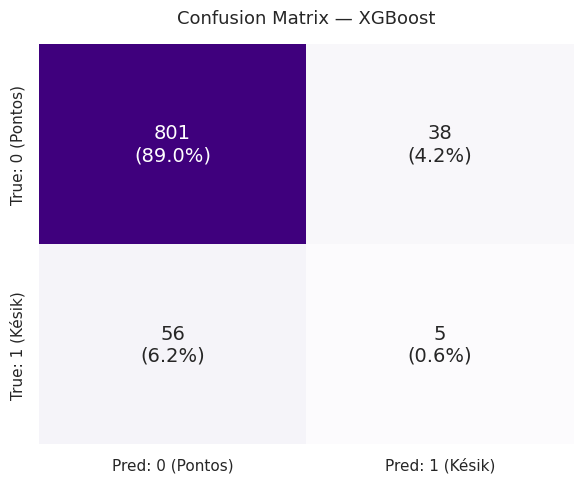

In [0]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, predictions["XGBoost"]["y_pred"])
cm_pct = cm / cm.sum() * 100
labels = [[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)]

sns.heatmap(cm, annot=labels, fmt='', cmap='Purples', cbar=False, 
            annot_kws={"size": 14}, ax=ax,
            xticklabels=["Pred: 0 (Pontos)", "Pred: 1 (Késik)"],
            yticklabels=["True: 0 (Pontos)", "True: 1 (Késik)"])
ax.set_title("Confusion Matrix — XGBoost", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

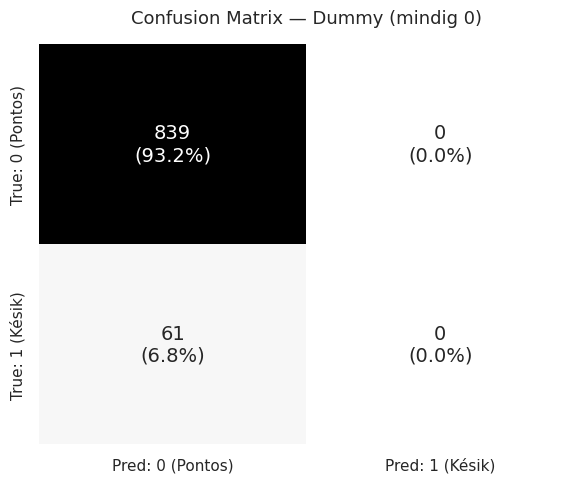

In [0]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, predictions["Dummy"]["y_pred"])
cm_pct = cm / cm.sum() * 100
labels = [[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)]

sns.heatmap(cm, annot=labels, fmt='', cmap='Greys', cbar=False, 
            annot_kws={"size": 14}, ax=ax,
            xticklabels=["Pred: 0 (Pontos)", "Pred: 1 (Késik)"],
            yticklabels=["True: 0 (Pontos)", "True: 1 (Késik)"])
ax.set_title("Confusion Matrix — Dummy (mindig 0)", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

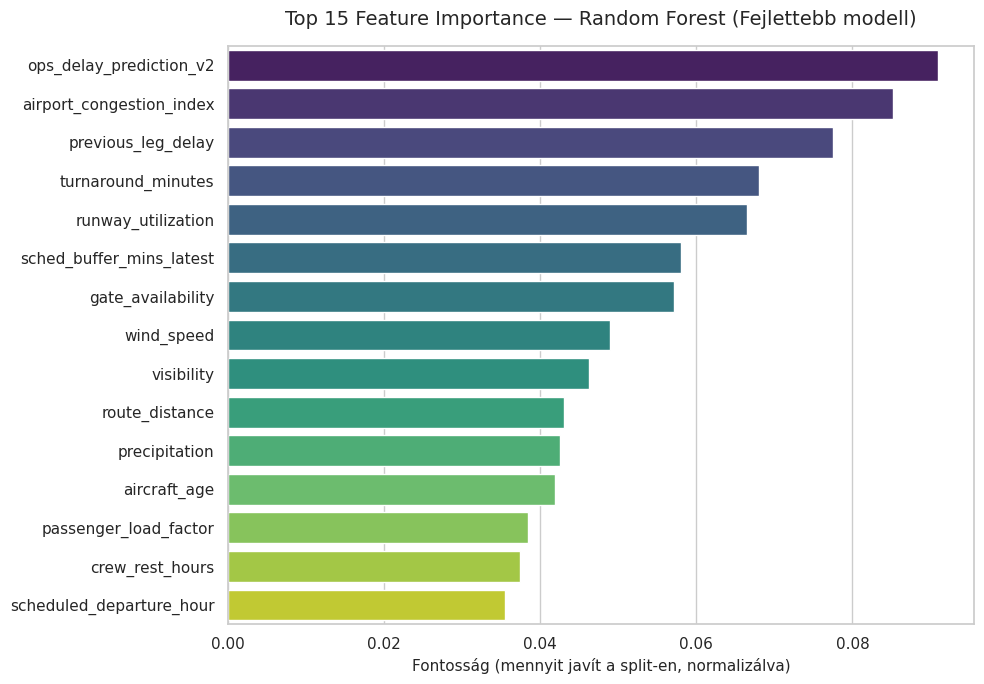

In [0]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=rf_importance, x="Importance", y="Feature", 
            hue="Feature", palette="viridis", legend=False, ax=ax)
ax.set_title("Top 15 Feature Importance — Random Forest (Fejlettebb modell)", fontsize=14, pad=15)
ax.set_xlabel("Fontosság (mennyit javít a split-en, normalizálva)", fontsize=11)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

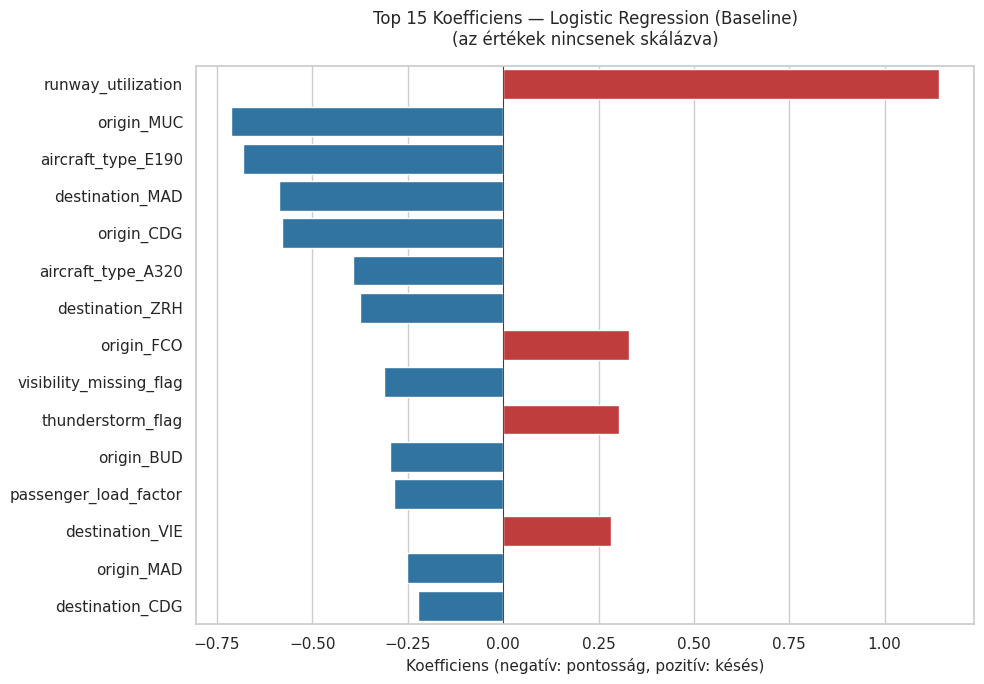

In [0]:
log_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_reg.coef_[0]
})
log_importance["Abs"] = log_importance["Coefficient"].abs()
log_importance = log_importance.sort_values("Abs", ascending=False).head(15)

colors = ['#d62728' if x > 0 else '#1f77b4' for x in log_importance["Coefficient"]]

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=log_importance, x="Coefficient", y="Feature", 
            hue="Feature", palette=colors, legend=False, ax=ax)
ax.set_title("Top 15 Koefficiens — Logistic Regression (Baseline)\n"
             "(az értékek nincsenek skálázva)", 
             fontsize=12, pad=15)
ax.set_xlabel("Koefficiens (negatív: pontosság, pozitív: késés)", fontsize=11)
ax.set_ylabel("")
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()